In [50]:
import sys
import os

import numpy as np
import geopandas as gpd
import xarray as xr
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, LogFormatter
from matplotlib import colors
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from matplotlib.ticker import PercentFormatter

import seaborn as sns

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from scipy.stats import ttest_ind, ks_2samp
from numba import njit, prange
from scipy.stats import mannwhitneyu
from scipy.stats import kruskal
from scipy.stats import spearmanr


project_root = "/glade/u/home/spatrin"
FIG_DIR = f"{project_root}/final_figures"
os.makedirs(FIG_DIR, exist_ok=True)

src_path = os.path.join(project_root, "src")

if src_path not in sys.path:
    sys.path.append(src_path)

print("Project root:", project_root)

Project root: /glade/u/home/spatrin


In [2]:
from utils import *
from data_loading import *
from pipeline import *
from spatial_utils import *
from geo_utils import *
from conversion import *
from aggregation import *

In [3]:
FIRE_ORDER = FIRE_TYPES
ACRES_TO_KM2 = 0.00404686

print("Fire type order used throughout:", FIRE_ORDER)

Fire type order used throughout: ['Agricultural', 'Prescribed', 'Wildfire']


In [4]:
sns.set_theme(style="whitegrid", context="paper")

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.frameon": False,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def savefig(fig, name):
    """Save a figure into FIG_DIR using a consistent naming convention."""
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, dpi=300, bbox_inches="tight", transparent=False)
    return path

In [5]:
cmap = plt.cm.Reds

cmap_trim = mcolors.LinearSegmentedColormap.from_list(
    "Reds_trim",
    cmap(np.linspace(0.3, 1, 256))
)

In [6]:
epa = load_epa_data()
epa_june = filter_june(epa)

gdf_june = gpd.GeoDataFrame(
    epa_june,
    geometry=gpd.points_from_xy(epa_june["longitude"], epa_june["latitude"]),
    crs="EPSG:4326"
)

print(f"Full-year EPA fires : {len(epa):,}")
print(f"June EPA fires      : {len(epa_june):,}")

Full-year EPA fires : 79,563
June EPA fires      : 2,771


In [7]:
# --- FINN: June 2022, gridded + converted to tons/day ---
finn_data = load_finn_june_processed()

lat = finn_data["lat"].values
lon = finn_data["lon"].values
pm_tons = finn_data["pm_tons"]     # (time, lat, lon), tons/day
pm_total = finn_data["pm_total"]   # (lat, lon), June total
pm_daily = finn_data["pm_daily"]   # (time,), June daily total

ga_mask = get_georgia_mask(lat, lon)

print("FINN grid shape (time, lat, lon):", pm_tons.shape)
print("Georgia grid cells:", int(np.sum(ga_mask)))

/glade/u/home/spatrin/src/data_loading.py:42: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(


FINN grid shape (time, lat, lon): (30, 1799, 3600)
Georgia grid cells: 1466


In [8]:
finn_annual = load_finn_annual_processed()

pm_annual_total = finn_annual["pm_total"]
annual_time = finn_annual["time"]

/glade/u/home/spatrin/src/data_loading.py:42: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(


### Methods

In [9]:
def cliffs_delta(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    n_x = len(x)
    n_y = len(y)

    gt = 0
    lt = 0

    for xi in x:
        gt += np.sum(xi > y)
        lt += np.sum(xi < y)

    return (gt - lt) / (n_x * n_y)

def summarize_skewed(x):
    return pd.Series({
        "N": len(x),
        "Median": np.median(x),
        "Q1": np.percentile(x,25),
        "Q3": np.percentile(x,75),
        "P95": np.percentile(x,95),
        "Total": np.sum(x)
    })

#### EPA

**Figure 1.** EPA fire locations (sized by reported PM$_{2.5}$) alongside the same fires gridded onto the FINN 0.1° lattice.

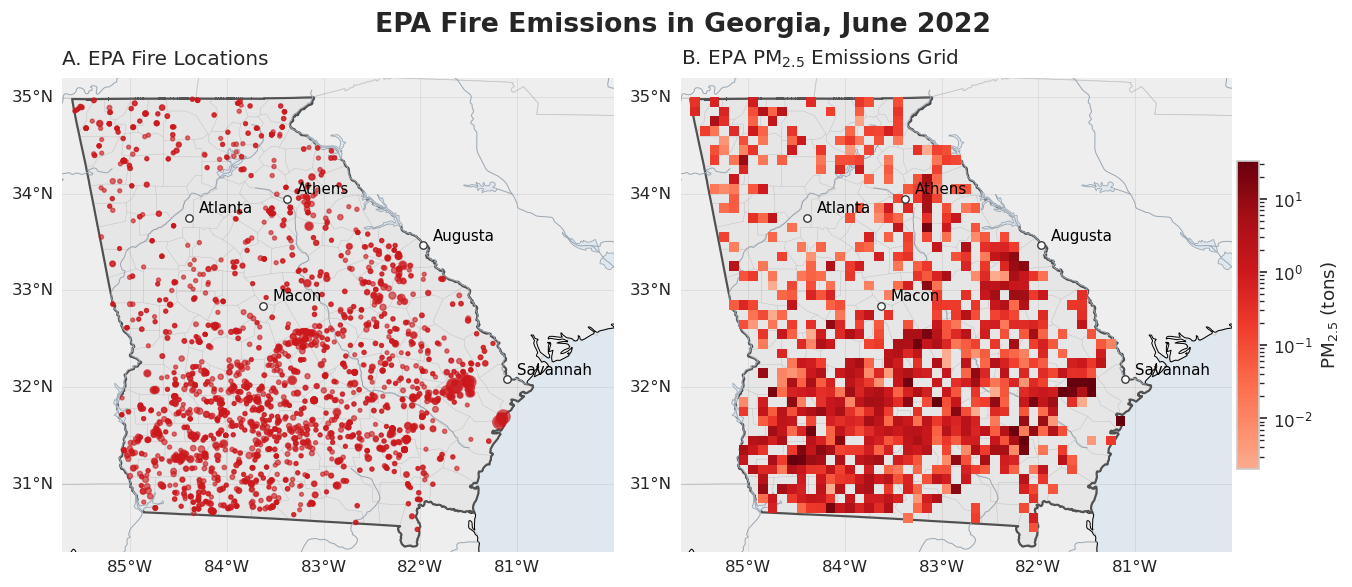

In [10]:
# --- Figure 1: EPA fire locations + gridded PM2.5 emissions ---
epa_grid_pm25 = epa_to_finn_grid(gdf_june, lat, lon, weight_type="pm25")
epa_grid_pm25 = apply_ga_mask(epa_grid_pm25, ga_mask)

plot_grid = epa_grid_pm25.copy()
plot_grid[plot_grid <= 0] = np.nan

cmap_reds = mcolors.LinearSegmentedColormap.from_list(
    "reds_trim", plt.cm.Reds(np.linspace(0.3, 1, 256))
)

vmin = np.nanpercentile(plot_grid, 1)
vmax = np.nanpercentile(plot_grid, 99)
norm = LogNorm(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(
    1, 2, figsize=(12, 5),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
fig.subplots_adjust(left=0.05, right=0.9, bottom=0.08, top=0.87, wspace=0.02)

# Panel A: EPA point locations, sized by reported PM2.5
ax = axes[0]
basemap(ax)
vals = gdf_june["pm2.5"].fillna(0).values
vals_sqrt = np.sqrt(vals)
sizes = 5 + (vals_sqrt / (vals_sqrt.max() + 1e-6)) * 80
ax.scatter(
    gdf_june.geometry.x, gdf_june.geometry.y,
    s=sizes, color="#cb181d", alpha=0.6,
    transform=ccrs.PlateCarree(), zorder=4
)
ax.set_title("A. EPA Fire Locations", fontsize=12, pad=8, loc="left")

# Panel B: EPA gridded onto the FINN lattice
ax = axes[1]
basemap(ax)
mesh = ax.pcolormesh(
    lon, lat, plot_grid, cmap=cmap_reds, norm=norm,
    shading="nearest", zorder=4
)
cax = inset_axes(
    axes[1], width="4%", height="65%", loc="center right",
    bbox_to_anchor=(0.05, 0., 1, 1), bbox_transform=axes[1].transAxes, borderpad=0
)
cbar = fig.colorbar(mesh, cax=cax)
cbar.set_label("PM$_{2.5}$ (tons)", fontsize=11)
cbar.ax.tick_params(labelsize=10)
ax.set_title("B. EPA PM$_{2.5}$ Emissions Grid", fontsize=12, pad=8, loc="left")

fig.suptitle("EPA Fire Emissions in Georgia, June 2022", fontsize=16, fontweight="bold", y=0.98)

savefig(fig, "fig01_epa_pt_grid.png")
plt.show()

In [11]:
epa_annual_summary = (
    epa
    .groupby("type")["pm2.5"]
    .apply(summarize_skewed)
)

display(epa_annual_summary)

type                
Agricultural  N         16704.000000
              Median        0.056271
              Q1            0.020478
              Q3            0.204782
              P95           0.819128
              Total      3259.254103
Prescribed    N         55926.000000
              Median        0.262079
              Q1            0.055368
              Q3            1.332608
              P95           6.265829
              Total     98155.099630
Wildfire      N          6933.000000
              Median        0.038021
              Q1            0.007801
              Q3            0.189272
              P95           1.667189
              Total      4140.379911
Name: pm2.5, dtype: float64

#### FINN

In [27]:
june_vals = pm_plot[np.isfinite(pm_plot)]
annual_vals = annual_grid[np.isfinite(annual_grid)]

all_vals = np.concatenate([june_vals, annual_vals])

common_vmin = np.nanpercentile(all_vals, 1)
common_vmax = np.nanpercentile(all_vals, 99)

norm = LogNorm(vmin=common_vmin, vmax=common_vmax)

**Figure 2.** Total FINN PM$_{2.5}$ emissions for Georgia, June 2022.

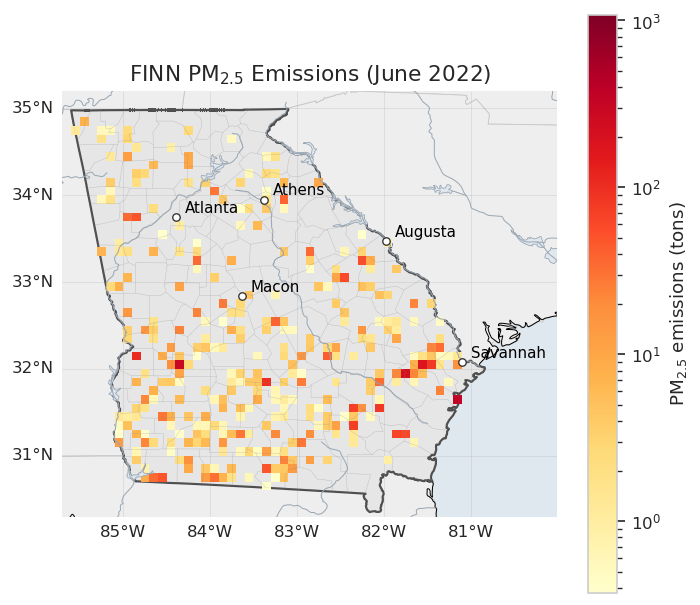

In [28]:
# --- Figure 2: FINN PM2.5 emissions map ---
fig, ax = basemap()

pm_plot = apply_ga_mask(pm_total.values, ga_mask)
pm_plot[pm_plot <= 1e-6] = np.nan

mesh = ax.pcolormesh(
    lon, lat, pm_plot, cmap="YlOrRd", norm=norm,
    transform=ccrs.PlateCarree(), shading="nearest", zorder=2
)

cbar = fig.colorbar(mesh, ax=ax, shrink=0.85, extend="neither")
cbar.set_label(r"PM$_{2.5}$ emissions (tons)")

ax.set_title("FINN PM$_{2.5}$ Emissions (June 2022)", fontsize=13)

plt.tight_layout()
savefig(fig, "fig02_finn_pm25_emissions.png")
plt.show()

In [29]:
annual_grid = np.array(pm_annual_total)

annual_grid = apply_ga_mask(
    annual_grid,
    ga_mask
)

annual_grid[
    annual_grid <= 1e-6
] = np.nan

***Figure 2B.***
Annual FINN PM2.5 Emissions (2022)

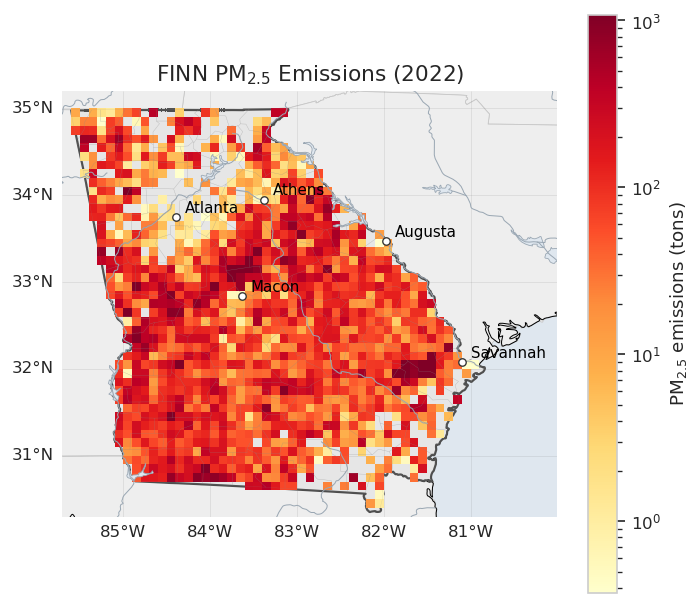

In [30]:
fig, ax = basemap()

mesh = ax.pcolormesh(
    lon, lat, annual_grid, cmap="YlOrRd", norm=norm,
    transform=ccrs.PlateCarree(), shading="nearest", zorder=2
)

cbar = fig.colorbar(mesh, ax=ax, shrink=0.85, extend="neither")
cbar.set_label(r"PM$_{2.5}$ emissions (tons)")

ax.set_title("FINN PM$_{2.5}$ Emissions (2022)", fontsize=13)

plt.tight_layout()
savefig(fig, "fig02b_finn_annual_pm25_emissions.png")
plt.show()

In [15]:
june_grid = np.array(
    finn_annual["pm_tons"]
    .sel(time=finn_annual["time"].dt.month == 6)
    .sum(dim="time")
)

june_grid = apply_ga_mask(
    june_grid,
    ga_mask
)

june_total_pm25 = pm_total.sum().values

annual_total_pm25 = finn_annual["pm_total"].sum().values


print(f"June total: {june_total_pm25:,.0f} tons")
print(f"Annual total: {annual_total_pm25:,.0f} tons")

print(
    f"June contribution = "
    f"{100*june_total_pm25/annual_total_pm25:.1f}%"
)

June total: 3,375,202 tons
Annual total: 64,242,456 tons
June contribution = 5.3%


In [16]:
monthly_finn = (
    finn_annual["pm_tons"]
    .sum(dim=["lat","lon"])
    .groupby("time.month")
    .sum()
)

Text(0.5, 0, 'Month')

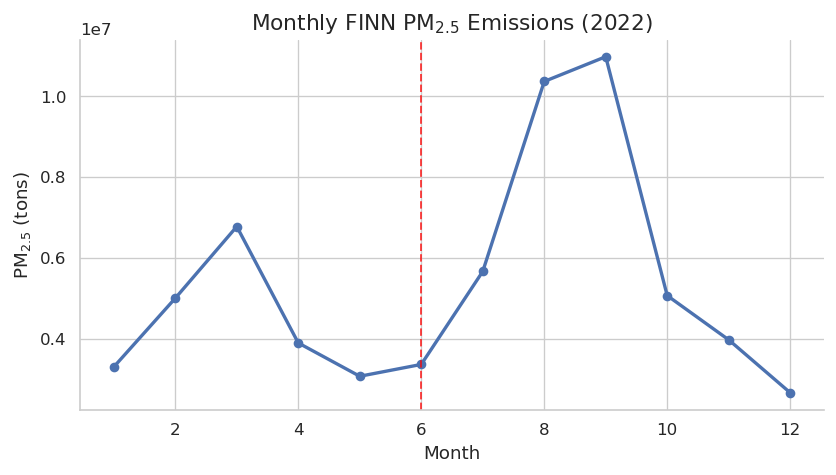

In [17]:
plt.figure(figsize=(8,4))

plt.plot(
    monthly_finn["month"],
    monthly_finn,
    marker="o",
    linewidth=2
)

plt.axvline(
    6,
    ls="--",
    color="red",
    alpha=0.7
)

plt.title(
    "Monthly FINN PM$_{2.5}$ Emissions (2022)"
)

plt.ylabel("PM$_{2.5}$ (tons)")
plt.xlabel("Month")

## Results

### General EPA Analysis

Fire counts and seasonal trends across all of 2022, before narrowing to the June study perio.


**Figure 3.** Total EPA fire events by type, full year 2022.

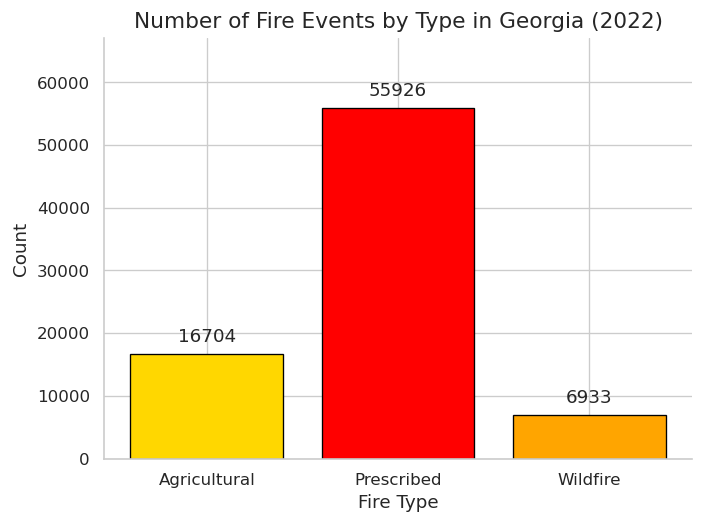

In [22]:
# --- Figure 3: fire counts by type, full year 2022 ---
counts_full = epa["type"].value_counts().reindex(FIRE_ORDER)
colors_full = [FIRE_COLORS[t] for t in FIRE_ORDER]

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(counts_full.index, counts_full.values, color=colors_full, edgecolor="black")

ax.bar_label(
    ax.containers[0],
    padding=5
)
ax.set_ylim(0, counts_full.max() * 1.2)

ax.set_title("Number of Fire Events by Type in Georgia (2022)")
ax.set_xlabel("Fire Type")
ax.set_ylabel("Count")
sns.despine(ax=ax)

plt.tight_layout()
savefig(fig, "fig03_fire_counts_2022.png")
plt.show()

In [23]:
epa.groupby("type")["pm2.5"].apply(
    summarize_skewed
)

type                
Agricultural  N         16704.000000
              Median        0.056271
              Q1            0.020478
              Q3            0.204782
              P95           0.819128
              Total      3259.254103
Prescribed    N         55926.000000
              Median        0.262079
              Q1            0.055368
              Q3            1.332608
              P95           6.265829
              Total     98155.099630
Wildfire      N          6933.000000
              Median        0.038021
              Q1            0.007801
              Q3            0.189272
              P95           1.667189
              Total      4140.379911
Name: pm2.5, dtype: float64

In [24]:
ag = epa.loc[
    epa.type=="Agricultural",
    "pm2.5"
]

pr = epa.loc[
    epa.type=="Prescribed",
    "pm2.5"
]

wf = epa.loc[
    epa.type=="Wildfire",
    "pm2.5"
]

H,p = kruskal(
    ag,
    pr,
    wf
)

print(
    f"Kruskal-Wallis H={H:.2f}, p={p:.3e}"
)

Kruskal-Wallis H=8112.85, p=0.000e+00


**Figure 4.** Monthly fire-count trends by type across 2022 (time series).

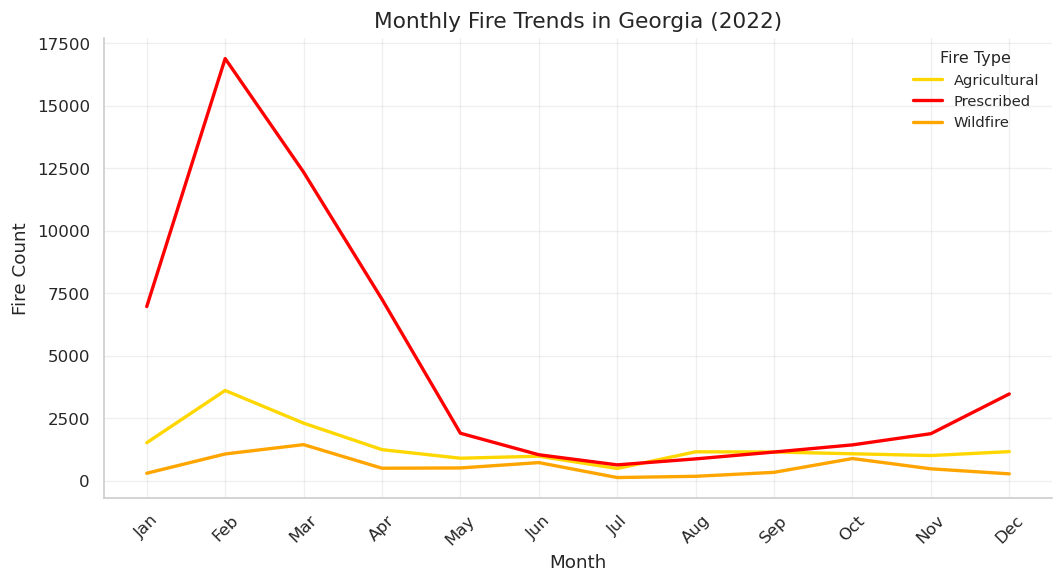

In [25]:
# --- Figure 4: monthly fire trends, 2022 ---
monthly_counts = (
    epa.groupby(["month", "type"]).size().unstack().reindex(columns=FIRE_ORDER)
)

fig, ax = plt.subplots(figsize=(9, 5))
for t in FIRE_ORDER:
    ax.plot(monthly_counts.index, monthly_counts[t], label=t, color=FIRE_COLORS[t], linewidth=2)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTHS_LABELS, rotation=45)

ax.set_title("Monthly Fire Trends in Georgia (2022)")
ax.set_xlabel("Month")
ax.set_ylabel("Fire Count")
ax.grid(alpha=0.3)
ax.legend(title="Fire Type")
sns.despine(ax=ax)

plt.tight_layout()
savefig(fig, "fig04_monthly_fire_trends.png")
plt.show()

**Figure 5.** Monthly fire emission trends by type across 2022 (time series).

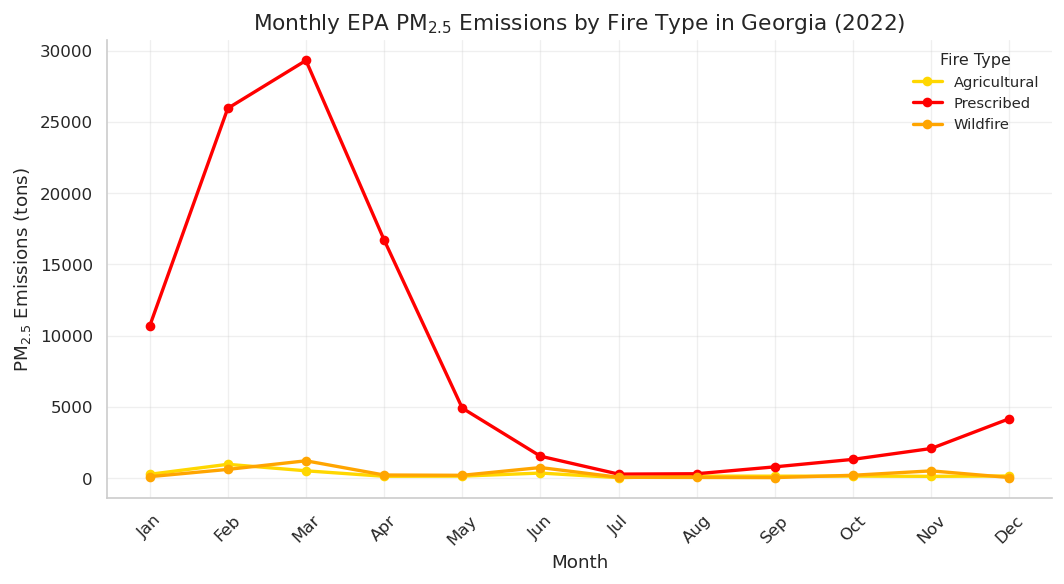

In [33]:
monthly_pm25 = (
    epa.groupby(["month", "type"])["pm2.5"]
       .sum()
       .unstack()
       .reindex(columns=FIRE_ORDER)
)

fig, ax = plt.subplots(figsize=(9, 5))

for t in FIRE_ORDER:
    ax.plot(
        monthly_pm25.index,
        monthly_pm25[t],
        label=t,
        color=FIRE_COLORS[t],
        linewidth=2,
        marker="o"
    )

ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTHS_LABELS, rotation=45)

ax.set_title("Monthly EPA PM$_{2.5}$ Emissions by Fire Type in Georgia (2022)")
ax.set_xlabel("Month")
ax.set_ylabel("PM$_{2.5}$ Emissions (tons)")
ax.legend(title="Fire Type")
ax.grid(alpha=0.3)

sns.despine(ax=ax)

plt.tight_layout()
# savefig(fig, "fig05_monthly_pm25_by_type.png")
plt.show()

#### Statistical Evaluation of June Relative to the Full Year

In [34]:
other = epa.loc[
    epa.month != 6,
    "pm2.5"
]

june = epa.loc[
    epa.month == 6,
    "pm2.5"
]

u,p = mannwhitneyu(
    june,
    other,
    alternative="two-sided"
)

delta = cliffs_delta(
    june,
    other
)
print(
    f"MWU p={p:.3e}"
)

print(
    f"Cliff's delta={delta:.3f}"
)

MWU p=1.334e-68
Cliff's delta=-0.195


#### June Restriction

**Figure 5.** Total EPA fire events by type, restricted to June 2022 (the study period).

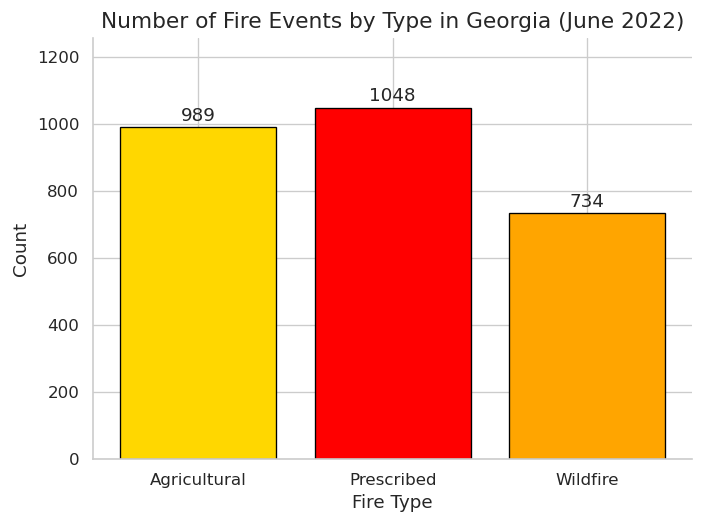

type
Agricultural    35.7
Prescribed      37.8
Wildfire        26.5
Name: percent_of_june_fires, dtype: float64

In [35]:
# --- Figure 5: fire counts by type, June 2022 ---
counts_june = epa_june["type"].value_counts().reindex(FIRE_ORDER)
colors_june = [FIRE_COLORS[t] for t in FIRE_ORDER]

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(counts_june.index, counts_june.values, color=colors_june, edgecolor="black")
add_bar_labels(ax, counts_june.values)
ax.set_ylim(0, counts_june.max() * 1.2)
ax.set_title("Number of Fire Events by Type in Georgia (June 2022)")
ax.set_xlabel("Fire Type")
ax.set_ylabel("Count")
sns.despine(ax=ax)

plt.tight_layout()
savefig(fig, "fig05_fire_counts_june2022.png")
plt.show()

(counts_june / counts_june.sum() * 100).round(1).rename("percent_of_june_fires")

### Analyzing FINN Detection Performance

Each EPA fire is classified as **matched** (a FINN grid cell with nonzero PM$_{2.5}$ falls in the same location on the same day) or **missed**, following `classify_missed_fires`. This fire-level table (`fire_match_df`) underlies the detection-rate figures and tables below.

In [36]:
def classify_all_days(gdf, finn, lat, lon):
    """Classify every EPA fire in `gdf` as matched/missed using the nearest-day FINN field."""
    results = []
    for date in sorted(gdf["date"].dt.normalize().unique()):
        epa_day = gdf[gdf["date"].dt.normalize() == date]
        if len(epa_day) == 0:
            continue
        finn_day = finn["pm_tons"].sel(time=date, method="nearest").values
        results.append(classify_missed_fires(epa_day, finn_day, lat, lon))
    return pd.concat(results, ignore_index=True)

fire_match_df = classify_all_days(gdf_june, finn_data, lat, lon)
fire_match_df["area_km2"] = fire_match_df["area"] * ACRES_TO_KM2
fire_match_df["Detection Status"] = fire_match_df["matched"].map({1: "Detected", 0: "Missed"})

print(f"Total fires classified : {len(fire_match_df):,}")
print(f"Detected               : {int(fire_match_df['matched'].sum()):,}")
print(f"Missed                 : {int((fire_match_df['matched'] == 0).sum()):,}")

Total fires classified : 2,771
Detected               : 260
Missed                 : 2,511


#### Spatial pattern of missed fires

**Figure 6.** Spatial distribution of missed EPA fires (grid-cell counts, summed over June), overall and split by fire typ
`.

In [37]:
# --- grid edges & per-day FINN/EPA lookups for the spatial miss-rate maps ---
dlat = lat[1] - lat[0]
dlon = lon[1] - lon[0]
lat_edges = np.concatenate([[lat[0] - dlat / 2], lat + dlat / 2])
lon_edges = np.concatenate([[lon[0] - dlon / 2], lon + dlon / 2])

epa_dates = pd.to_datetime(gdf_june["date"]).dt.floor("D").values
epa_lat_pts = gdf_june.geometry.y.values
epa_lon_pts = gdf_june.geometry.x.values
epa_type_pts = gdf_june["type"].values

unique_dates, inverse_idx = np.unique(epa_dates, return_inverse=True)
date_groups = [np.where(inverse_idx == i)[0] for i in range(len(unique_dates))]

finn_times = pd.to_datetime(finn_data["time"].values).floor("D").values
time_lookup = np.array([np.argmin(np.abs(finn_times - d)) for d in unique_dates])

ga_mask_bool = ga_mask.astype(np.bool_)
nlat, nlon = len(lat), len(lon)


@njit(parallel=True)
def _apply_mask_fast(grid, mask):
    for i in prange(grid.shape[0]):
        for j in range(grid.shape[1]):
            if not mask[i, j]:
                grid[i, j] = np.nan
    return grid


@njit
def _compute_miss_fast(epa_grid, finn_grid, threshold=1e-3):
    miss = np.zeros_like(epa_grid)
    for i in range(epa_grid.shape[0]):
        for j in range(epa_grid.shape[1]):
            if epa_grid[i, j] > 0 and finn_grid[i, j] <= threshold:
                miss[i, j] = 1
    return miss

In [38]:
miss_ag = np.zeros((nlat, nlon))
miss_prescribed = np.zeros((nlat, nlon))
miss_wildfire = np.zeros((nlat, nlon))
miss_total = np.zeros((nlat, nlon))

for i in range(len(unique_dates)):
    inds = date_groups[i]
    if len(inds) == 0:
        continue

    lat_pts, lon_pts, types = epa_lat_pts[inds], epa_lon_pts[inds], epa_type_pts[inds]

    epa_grid, _, _ = np.histogram2d(lat_pts, lon_pts, bins=[lat_edges, lon_edges])
    epa_grid = _apply_mask_fast(epa_grid, ga_mask_bool)

    finn_grid = pm_tons.isel(time=time_lookup[i]).values.copy()
    finn_grid = _apply_mask_fast(finn_grid, ga_mask_bool)

    miss = _compute_miss_fast(epa_grid, finn_grid)

    for type_name, target in [
        ("Agricultural", miss_ag),
        ("Prescribed", miss_prescribed),
        ("Wildfire", miss_wildfire),
    ]:
        type_mask = types == type_name
        if np.any(type_mask):
            type_grid, _, _ = np.histogram2d(
                lat_pts[type_mask], lon_pts[type_mask], bins=[lat_edges, lon_edges]
            )
            target += (type_grid > 0) * miss

    miss_total += miss

for grid in (miss_ag, miss_prescribed, miss_wildfire, miss_total):
    grid[grid == 0] = np.nan

print("Total missed grid-days:", np.nansum(miss_total))
print("  Agricultural:", np.nansum(miss_ag))
print("  Prescribed  :", np.nansum(miss_prescribed))
print("  Wildfire    :", np.nansum(miss_wildfire))

Total missed grid-days: 1623.0
  Agricultural: 848.0
  Prescribed  : 468.0
  Wildfire    : 343.0


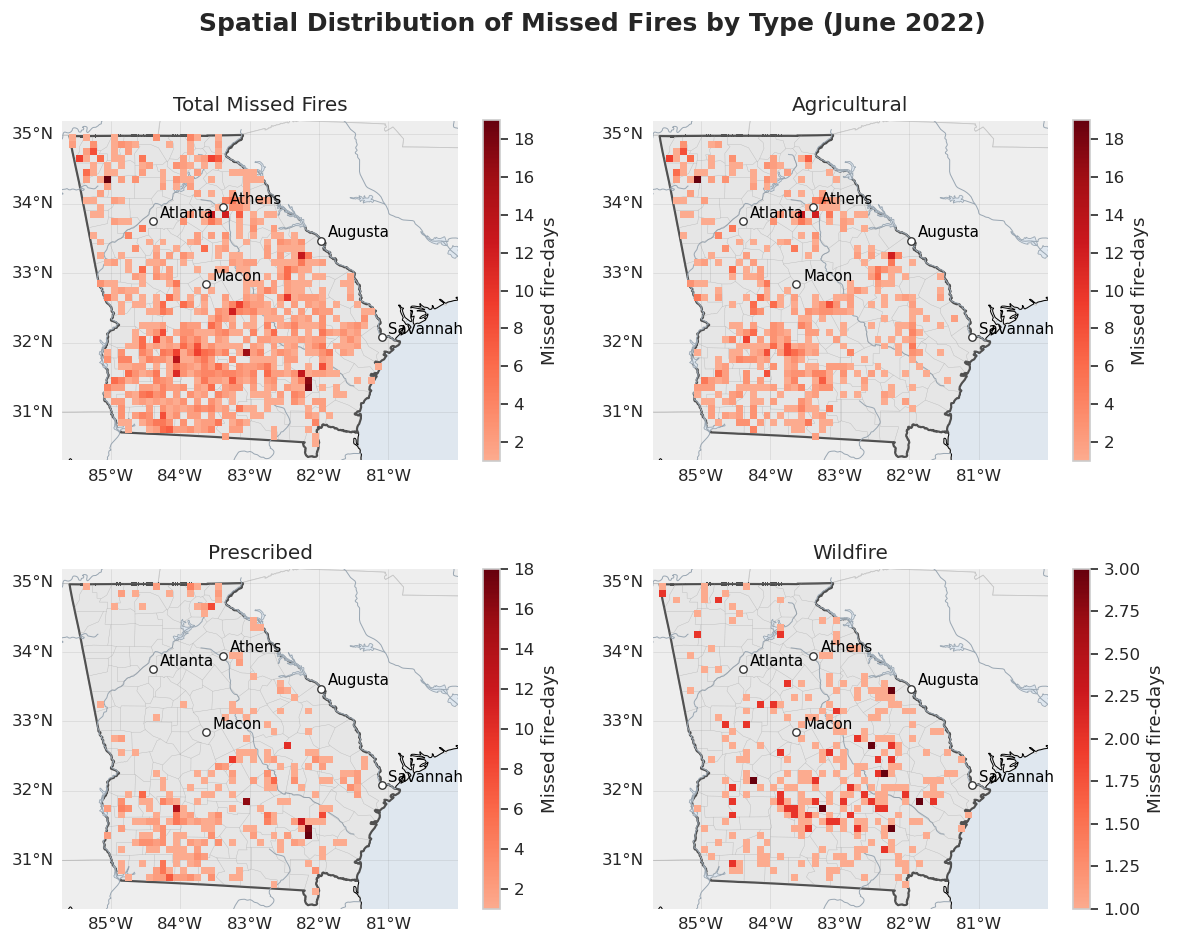

In [39]:
fig, axes = plt.subplots(
    2, 2, figsize=(10, 8),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

panels = [
    ("Total Missed Fires", miss_total),
    ("Agricultural", miss_ag),
    ("Prescribed", miss_prescribed),
    ("Wildfire", miss_wildfire),
]

for ax, (title, grid) in zip(axes.ravel(), panels):
    basemap(ax)
    mesh = ax.pcolormesh(
        lon, lat, grid, transform=ccrs.PlateCarree(),
        shading="nearest", cmap=cmap_trim, zorder=5
    )
    ax.set_title(title, fontsize=12)
    plt.colorbar(mesh, ax=ax, shrink=0.8, label="Missed fire-days")

fig.suptitle("Spatial Distribution of Missed Fires by Type (June 2022)", fontsize=15, fontweight="bold", y=1.0)

plt.tight_layout()
savefig(fig, "fig06_miss_rate_by_type_maps.png")
plt.show()

#### Detection performance: confusion matrix

**Table 1.** Daily spatiotemporal detection metrics (grid-cell TP/FN/FP, using `run_daily_spatiotemporal_analysis`) by fire type, with a combined total row.

In [40]:
overall_metrics = run_daily_spatiotemporal_analysis(gdf_june, finn_data, lat, lon)

rows = []
for fire_type in FIRE_ORDER:
    subset = gdf_june[gdf_june["type"] == fire_type]
    m = run_daily_spatiotemporal_analysis(subset, finn_data, lat, lon)
    rows.append({
        "Fire Type": fire_type,
        "TP": m["TP"], "FN": m["FN"], "FP": m["FP"],
        "N": m["TP"] + m["FN"],
        "Precision": m["precision"],
        "Recall": m["recall"],
        "Miss Rate": m["FN"] / (m["TP"] + m["FN"] + 1e-6),
    })

rows.append({
    "Fire Type": "Total (Combined)",
    "TP": overall_metrics["TP"], "FN": overall_metrics["FN"], "FP": overall_metrics["FP"],
    "N": overall_metrics["TP"] + overall_metrics["FN"],
    "Precision": overall_metrics["precision"],
    "Recall": overall_metrics["recall"],
    "Miss Rate": overall_metrics["FN"] / (overall_metrics["TP"] + overall_metrics["FN"] + 1e-6),
})

confusion_summary = pd.DataFrame(rows).set_index("Fire Type")
confusion_summary[["Precision", "Recall", "Miss Rate"]] = (
    confusion_summary[["Precision", "Recall", "Miss Rate"]].round(3)
)
confusion_summary

,TP,FN,FP,N,Precision,Recall,Miss Rate
Fire Type,,,,,,,
Agricultural,67,848,452,915,0.129,0.073,0.927
Prescribed,57,468,462,525,0.110,0.109,0.891
Wildfire,27,343,492,370,0.052,0.073,0.927
Total (Combined),139,1623,380,1762,0.268,0.079,0.921


#### Detection by fire type

**Figure 7.*Fraction of EPA fires matched to FINN emissions by fire type.
Bars show the proportion of EPA fire records that were associated with at
least one FINN PM2.5-emitting grid cell during June 2022. Error bars
indicate 95% confidence intervals.s.

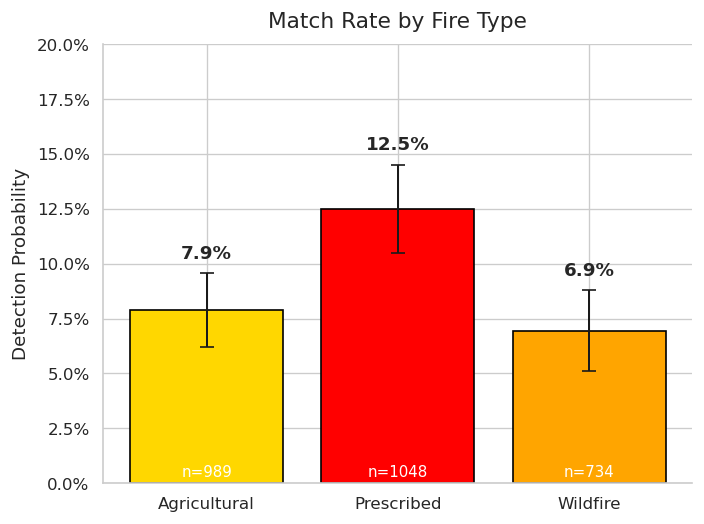

In [41]:
type_detection = (
    fire_match_df.groupby("type")["matched"]
    .agg(["mean", "count", "std"])
    .reindex(FIRE_ORDER)
    .reset_index()
)
type_detection["se"] = type_detection["std"] / np.sqrt(type_detection["count"])

fig, ax = plt.subplots(figsize=(6, 4.5))

bars = ax.bar(
    type_detection["type"], type_detection["mean"],
    yerr=1.96 * type_detection["se"],
    color=[FIRE_COLORS[t] for t in type_detection["type"]],
    edgecolor="black", linewidth=1.0, capsize=4
)

for bar, mean, se, n in zip(
    bars,
    type_detection["mean"],
    type_detection["se"],
    type_detection["count"]
):
    upper = mean + 1.96 * se

    ax.text(
        bar.get_x() + bar.get_width()/2,
        upper + 0.005,
        f"{mean:.1%}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

    ax.text(
        bar.get_x() + bar.get_width()/2,
        0.003,
        f"n={n}",
        ha="center",
        fontsize=9,
        color="white"
    )

ax.set_title("Match Rate by Fire Type", fontsize=13, pad=10)
ax.set_ylabel("Detection Probability")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylim(0, type_detection["mean"].max() * 1.6)
sns.despine(ax=ax)

plt.tight_layout()
savefig(fig, "fig07_detection_prob_by_type.png")
plt.show()

#### Detection by fire size

**Figure 8.* EPA–FINN match rates by fire-size quartile. Bars show the fraction of EPA fire records matched to FINN emissions, grouped by quartiles of reported PM₂.₅ emissions (A) and burned area (B). Error bars denote 95% Wilson confidence intervals for binomial proportions. Sample sizes are shown within bars. Match rates increase monotonically with both emissions and burned area, indicating that larger fires are more likely to be represented in the FINN inventory.n.

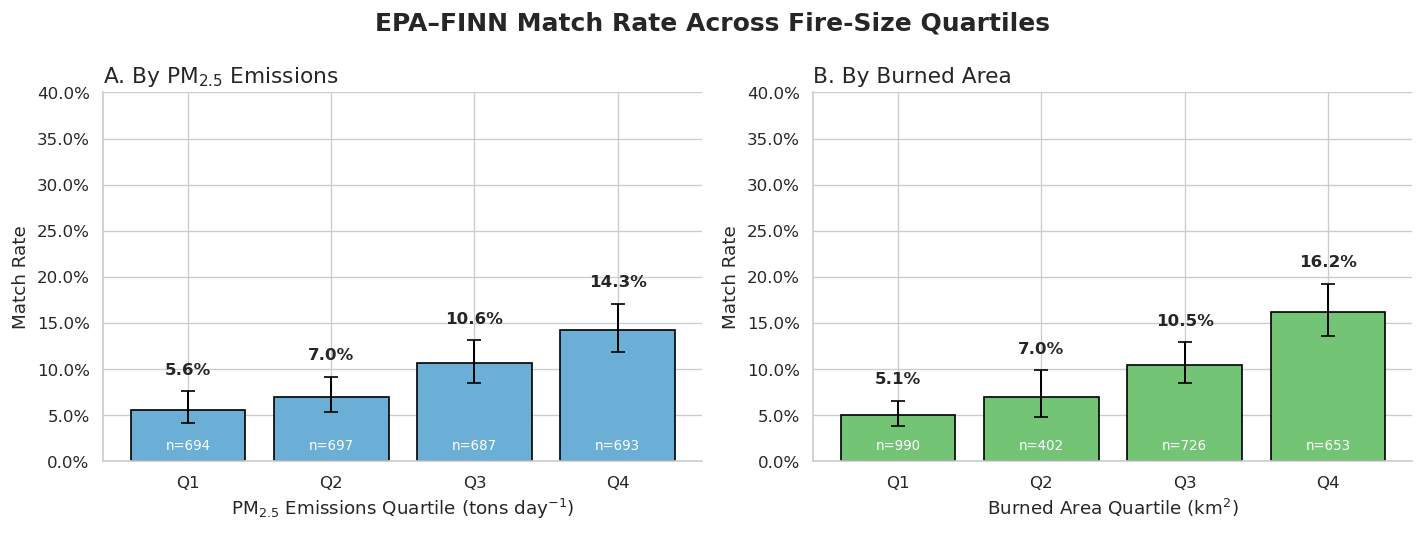

In [42]:
from statsmodels.stats.proportion import proportion_confint

fire_match_df["pm_bin"] = pd.qcut(
    fire_match_df["pm2.5"],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"],
    duplicates="drop"
)

fire_match_df["area_bin"] = pd.qcut(
    fire_match_df["area_km2"],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"],
    duplicates="drop"
)

def match_rate_summary(df, group_col):

    summary = (
        df.groupby(group_col, observed=True)["matched"]
        .agg(matches="sum", count="count")
        .reset_index()
    )

    summary["rate"] = summary["matches"] / summary["count"]

    ci_low = []
    ci_high = []

    for k, n in zip(summary["matches"], summary["count"]):

        low, high = proportion_confint(
            count=k,
            nobs=n,
            alpha=0.05,
            method="wilson"
        )

        ci_low.append(low)
        ci_high.append(high)

    summary["ci_low"] = ci_low
    summary["ci_high"] = ci_high

    return summary


pm_summary = match_rate_summary(fire_match_df, "pm_bin")
area_summary = match_rate_summary(fire_match_df, "area_bin")

pm_edges = fire_match_df["pm2.5"].quantile([0, .25, .5, .75, 1]).values
area_edges = fire_match_df["area_km2"].quantile([0, .25, .5, .75, 1]).values

pm_xticklabels = ["Q1", "Q2", "Q3", "Q4"]
area_xticklabels = ["Q1", "Q2", "Q3", "Q4"]

def plot_match_rate(ax, summary, xticklabels, xlabel, color):

    x = np.arange(len(summary))

    bars = ax.bar(
        x,
        summary["rate"],
        color=color,
        edgecolor="black",
        linewidth=1
    )

    lower = summary["rate"] - summary["ci_low"]
    upper = summary["ci_high"] - summary["rate"]

    ax.errorbar(
        x,
        summary["rate"],
        yerr=[lower, upper],
        fmt="none",
        color="black",
        capsize=4,
        lw=1.2
    )

    for xx, rate, hi, n in zip(
        x,
        summary["rate"],
        summary["ci_high"],
        summary["count"]
    ):

        ax.text(
            xx,
            hi + 0.015,
            f"{rate:.1%}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

        ax.text(
            xx,
            0.01,
            f"n={n}",
            ha="center",
            va="bottom",
            fontsize=8,
            color="white"
        )

    ax.set_xticks(x)
    ax.set_xticklabels(xticklabels)

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Match Rate")

    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set_ylim(0, 0.40)

    sns.despine(ax=ax)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

plot_match_rate(
    axes[0],
    pm_summary,
    pm_xticklabels,
    r"PM$_{2.5}$ Emissions Quartile (tons day$^{-1}$)",
    "#6baed6"
)
axes[0].set_title("A. By PM$_{2.5}$ Emissions", loc="left")

plot_match_rate(
    axes[1],
    area_summary,
    area_xticklabels,
    r"Burned Area Quartile (km$^2$)",
    "#74c476"
)
axes[1].set_title("B. By Burned Area", loc="left")

fig.suptitle(
    "EPA–FINN Match Rate Across Fire-Size Quartiles",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

savefig(fig, "fig08_match_rate_by_size_quartiles.png")
plt.show()

In [43]:
fire_match_df["log_pm"] = np.log10(fire_match_df["pm2.5"] + 1e-6)
fire_match_df["log_area"] = np.log10(fire_match_df["area_km2"] + 1e-6)

In [44]:
import statsmodels.formula.api as smf

pm_model_log = smf.logit(
    "matched ~ log_pm",
    data=fire_match_df
).fit()

print(pm_model_log.summary())

Optimization terminated successfully.
         Current function value: 0.302317
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                matched   No. Observations:                 2771
Model:                          Logit   Df Residuals:                     2769
Method:                           MLE   Df Model:                            1
Date:                Tue, 07 Jul 2026   Pseudo R-squ.:                 0.02888
Time:                        13:41:26   Log-Likelihood:                -837.72
converged:                       True   LL-Null:                       -862.64
Covariance Type:            nonrobust   LLR p-value:                 1.677e-12
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.8010      0.086    -20.956      0.000      -1.969      -1.633
log_pm         0.4859      0.

In [45]:
area_model_log = smf.logit(
    "matched ~ log_area",
    data=fire_match_df
).fit()

print(area_model_log.summary())

Optimization terminated successfully.
         Current function value: 0.297818
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                matched   No. Observations:                 2771
Model:                          Logit   Df Residuals:                     2769
Method:                           MLE   Df Model:                            1
Date:                Tue, 07 Jul 2026   Pseudo R-squ.:                 0.04333
Time:                        13:41:26   Log-Likelihood:                -825.25
converged:                       True   LL-Null:                       -862.64
Covariance Type:            nonrobust   LLR p-value:                 5.315e-18
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.2464      0.125     -9.952      0.000      -1.492      -1.001
log_area       0.6444      0.

In [46]:
print("Log PM pseudo-R²:", pm_model_log.prsquared)
print("Log Area pseudo-R²:", area_model_log.prsquared)

Log PM pseudo-R²: 0.028882336195334424
Log Area pseudo-R²: 0.043332458129562434


#### 3.2.5 Fire size distributions by detection status

**Figure 9.** PM$_{2.5}$ and burned-area distributions (violin + boxplot + jittered points), split by detection status. Statistical tests below support the annotated $p$-values.

In [51]:
matched_grp = fire_match_df[fire_match_df["matched"] == 1]
missed_grp = fire_match_df[fire_match_df["matched"] == 0]

t_pm, p_pm = ttest_ind(matched_grp["pm2.5"], missed_grp["pm2.5"], nan_policy="omit")
ks_pm, ksp_pm = ks_2samp(matched_grp["pm2.5"], missed_grp["pm2.5"])

t_area, p_area = ttest_ind(matched_grp["area"], missed_grp["area"], nan_policy="omit")
ks_area, ksp_area = ks_2samp(matched_grp["area"], missed_grp["area"])

print(f"PM2.5 : t={t_pm:.2f}, p={p_pm:.2e} | KS={ks_pm:.3f}, p={ksp_pm:.2e}")
print(f"Area  : t={t_area:.2f}, p={p_area:.2e} | KS={ks_area:.3f}, p={ksp_area:.2e}")

PM2.5 : t=4.71, p=2.65e-06 | KS=0.198, p=1.42e-08
Area  : t=8.50, p=3.02e-17 | KS=0.240, p=1.83e-12


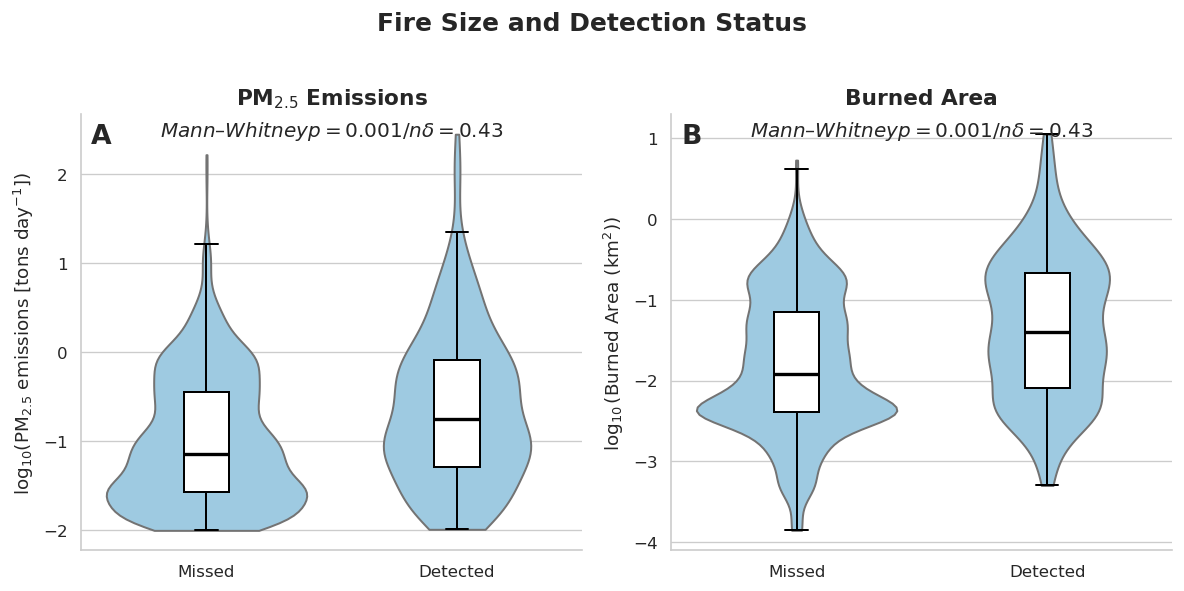

In [52]:
fire_match_df["log_pm25"] = np.log10(fire_match_df["pm2.5"] + 0.01)
fire_match_df["log_area"] = np.log10(fire_match_df["area_km2"] + 1e-4)  # area in km^2

violin_color = "#9ecae1"

fig, axes = plt.subplots(1, 2, figsize=(10, 4.8))


def violin_panel(ax, df, y_col, ylabel, panel_label, title, log_scale=False):
    sns.violinplot(data=df, x="Detection Status", y=y_col, inner=None,
                   color=violin_color, saturation=1, cut=0, linewidth=1.2, ax=ax)
    sns.boxplot(data=df, x="Detection Status", y=y_col, width=0.18, showcaps=True,
                fliersize=0,
                boxprops=dict(facecolor="white", edgecolor="black", linewidth=1.2),
                medianprops=dict(color="black", linewidth=2),
                whiskerprops=dict(color="black", linewidth=1.2),
                capprops=dict(color="black", linewidth=1.2), ax=ax)
    sample = df.sample(min(800, len(df)), random_state=42)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.text(0.02, 0.98, panel_label, transform=ax.transAxes, fontsize=16,
            fontweight="bold", va="top")
    ax.text(0.5, 0.95, r"$Mann–Whitney p = 0.001 /n δ = 0.43$", transform=ax.transAxes, ha="center", fontsize=12)
    sns.despine(ax=ax)


violin_panel(axes[0], fire_match_df, "log_pm25",
             r"log$_{10}$(PM$_{2.5}$ emissions [tons day$^{-1}$])", "A", r"PM$_{2.5}$ Emissions")

violin_panel(axes[1], fire_match_df, "log_area",
             r"$\log_{10}(\mathrm{Burned\ Area\ (km^2)})$", "B", "Burned Area")

fig.suptitle("Fire Size and Detection Status", fontsize=15, fontweight="bold", y=1.02)

plt.tight_layout()
savefig(fig, "fig09_size_vs_detection_violin.png")
plt.show()

#### Total emissions and burned area, by fire type

**Table 2.** Total, detected, and missed PM$_{2.5}$ emissions and burned area by fire type, with a combined total row — and the EPA vs. FINN total-emissions comparison referenced in the discussion.

In [53]:
def emissions_by_type(df):
    total = df.groupby("type").agg(
        total_pm25=("pm2.5", "sum"),
        total_area_km2=("area_km2", "sum"),
    )
    detected = df[df["matched"] == 1].groupby("type").agg(
        detected_pm25=("pm2.5", "sum"), detected_area_km2=("area_km2", "sum")
    )
    missed = df[df["matched"] == 0].groupby("type").agg(
        missed_pm25=("pm2.5", "sum"), missed_area_km2=("area_km2", "sum")
    )
    out = total.join(detected).join(missed).fillna(0)
    out["pct_missed_pm25"] = out["missed_pm25"] / out["total_pm25"] * 100
    out["pct_missed_area"] = out["missed_area_km2"] / out["total_area_km2"] * 100
    return out


emissions_table = emissions_by_type(fire_match_df).reindex(FIRE_ORDER)

total_row = pd.DataFrame({
    "total_pm25": [emissions_table["total_pm25"].sum()],
    "total_area_km2": [emissions_table["total_area_km2"].sum()],
    "detected_pm25": [emissions_table["detected_pm25"].sum()],
    "detected_area_km2": [emissions_table["detected_area_km2"].sum()],
    "missed_pm25": [emissions_table["missed_pm25"].sum()],
    "missed_area_km2": [emissions_table["missed_area_km2"].sum()],
}, index=["Total (Combined)"])
total_row["pct_missed_pm25"] = total_row["missed_pm25"] / total_row["total_pm25"] * 100
total_row["pct_missed_area"] = total_row["missed_area_km2"] / total_row["total_area_km2"] * 100

emissions_table = pd.concat([emissions_table, total_row])
emissions_table.round(2)

,total_pm25,total_area_km2,detected_pm25,detected_area_km2,missed_pm25,missed_area_km2,pct_missed_pm25,pct_missed_area
Agricultural,369.00,112.13,48.09,15.60,320.91,96.53,86.97,86.09
Prescribed,1550.95,167.18,766.80,71.92,784.15,95.26,50.56,56.98
Wildfire,754.74,39.74,50.40,3.36,704.35,36.38,93.32,91.54
Total (Combined),2674.69,319.04,865.28,90.88,1809.41,228.16,67.65,71.51


In [54]:
# --- EPA vs. FINN total PM2.5, Georgia, June 2022 ---
ga_pm_finn = apply_ga_mask(pm_tons.values, ga_mask)
finn_total_pm25 = np.nansum(ga_pm_finn)
epa_total_pm25 = gdf_june["pm2.5"].sum()

bias = finn_total_pm25 - epa_total_pm25
ratio = finn_total_pm25 / (epa_total_pm25 + 1e-6)

print(f"EPA total PM2.5 (June, GA)  : {epa_total_pm25:,.1f} tons")
print(f"FINN total PM2.5 (June, GA) : {finn_total_pm25:,.1f} tons")
print(f"Difference (FINN - EPA)     : {bias:,.1f} tons")
print(f"Ratio (FINN / EPA)          : {ratio:.2f}")

EPA total PM2.5 (June, GA)  : 2,674.7 tons
FINN total PM2.5 (June, GA) : 3,767.5 tons
Difference (FINN - EPA)     : 1,092.8 tons
Ratio (FINN / EPA)          : 1.41


### Annual vs June Representation Assessment


In [55]:
summary = pd.DataFrame({
    "Metric":[
        "Fire Count",
        "Total PM2.5",
        "Median PM2.5",
        "95th Percentile PM2.5"
    ],
    "2022 Full Year":[...],
    "June 2022":[...]
})

ValueError: All arrays must be of the same length

### limitations and future work

In [ ]:
fig, ax1 = plt.subplots(figsize=(8,4))

# EPA
ax1.plot(
    daily_stats['date'],
    daily_stats['epa_fires'],
    color='black',
    linewidth=2,
    label='EPA fires'
)

ax1.set_ylabel('EPA fires per day', color='black')
ax1.tick_params(axis='y', colors='black')

# FINN
ax2 = ax1.twinx()

ax2.plot(
    daily_stats['date'],
    daily_stats['finn_active_cells'],
    color='firebrick',
    linewidth=2,
    label='FINN active cells'
)

ax2.set_ylabel('FINN active cells per day', color='firebrick')
ax2.tick_params(axis='y', colors='firebrick')

plt.title('Daily Fire Activity: EPA vs FINN')
ax1.set_xlabel('Date')

fig.autofmt_xdate()
sns.despine()

plt.tight_layout()
plt.show()

In [ ]:
daily_confusion["daily_fires"] = (
    daily_confusion["TP"] +
    daily_confusion["FN"]
)

fig, ax = plt.subplots(figsize=(10,4))

ax.plot(
    daily_confusion["date"],
    daily_confusion["daily_fires"],
    color="black",
    linewidth=2,
    label="EPA Fires"
)

ax.plot(
    daily_confusion["date"],
    daily_confusion["TP"],
    color="#2ca25f",
    linewidth=2,
    label="Detected by FINN"
)

ax.set_ylabel("Fire Count")

ax.legend()

ax.set_title(
    "Daily EPA Fires and FINN Detections"
)

fig.autofmt_xdate()

plt.tight_layout()
plt.show()

In [ ]:
daily_confusion["Detected"] = daily_confusion["TP"]
daily_confusion["Missed"] = daily_confusion["FN"]

fig, ax = plt.subplots(figsize=(10,4))

ax.bar(
    daily_confusion["date"],
    daily_confusion["Detected"],
    color="#3182bd",
    label="Detected"
)

ax.bar(
    daily_confusion["date"],
    daily_confusion["Missed"],
    bottom=daily_confusion["Detected"],
    color="#d9d9d9",
    label="Missed"
)

ax.set_ylabel("EPA Fires")

ax.set_title(
    "Daily EPA Fires Detected and Missed by FINN"
)

ax.legend()

fig.autofmt_xdate()

plt.tight_layout()
plt.show()